This Is Part 2 Of The Data Analysis Project Which Requires Making Features And Transforming The Data In The Dataset Using The Cleaned Dataset From The First Part.

# The Imports And Cleaned Dataset:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Datasets/cleaned.csv')

# I dropped the order column because it was just the order of the rows and it didn't add any value to the dataset at all :P.

if 'Order' in df.columns:
    df = df.drop(columns=['Order'])
print(df.shape)

(2897, 81)


# Encoding:

In [2]:
# One-hot encode MS Zoning and Street
df = pd.get_dummies(df, columns=['MS Zoning', 'Street'], drop_first=True)

# Ranking
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

# Create a new numerical column based on the quality.
df['Exter_Qual_Score'] = df['Exter Qual'].map(qual_map)

# Log Transformation:

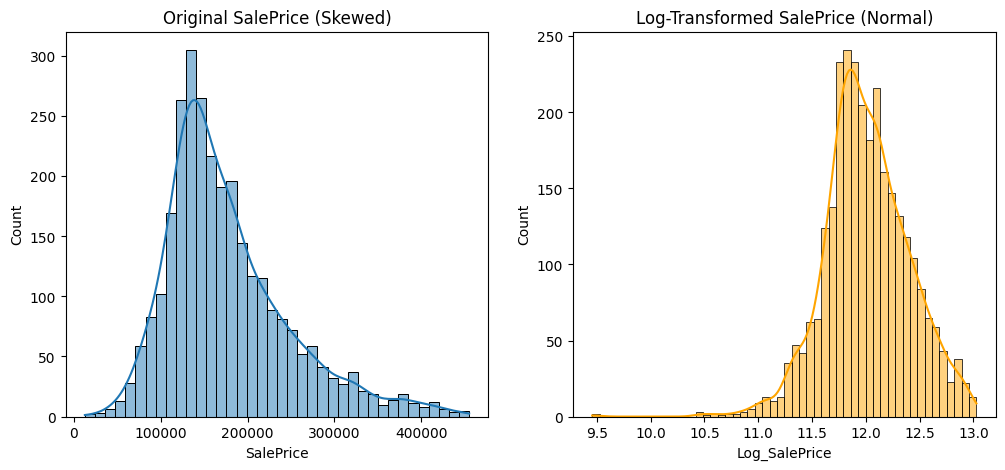

In [3]:
# Plot before and after to show the change
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True)
plt.title('Original SalePrice (Skewed)')

# Apply Log Transform
df['Log_SalePrice'] = np.log1p(df['SalePrice'])

plt.subplot(1, 2, 2)
sns.histplot(df['Log_SalePrice'], kde=True, color='orange')
plt.title('Log-Transformed SalePrice (Normal)')

plt.show()

# Creating Domain Features:

In [4]:
# 1. Price per Square Foot (Ratio)
# Use .replace(0, np.nan) to avoid "Division by Zero" errors
df['Price_per_SqFt'] = df['SalePrice'] / df['Gr Liv Area'].replace(0, np.nan)

# 2. Total Bathrooms (Combining features)
# Half baths are usually counted as 0.5 in real estate listings
df['Total_Bathrooms'] = df['Full Bath'] + (df['Bsmt Full Bath']) + (0.5 * (df['Half Bath'] + df['Bsmt Half Bath']))

# Interaction Feature:

In [5]:
# Interaction: Overall Quality multiplied by Overall Condition
df['Qual_x_Cond'] = df['Overall Qual'] * df['Overall Cond']

# Interaction: Total living area weighted by overall quality
df['Qual_Area_Interact'] = df['Overall Qual'] * df['Gr Liv Area']

# Binning:

In [6]:
# Calculate age at time of sale
df['House_Age'] = df['Yr Sold'] - df['Year Built']

# Bin into groups: New (0-10 years), Moderate (11-40), Old (41+)
df['Age_Group'] = pd.cut(df['House_Age'], 
                         bins=[-1, 10, 40, 200], 
                         labels=['New', 'Moderate', 'Old'])

# Standard Scalling:

In [7]:
scaler = StandardScaler()

# Scaling two numerical columns
cols_to_scale = ['Lot Area', 'Gr Liv Area']
df[[f'{c}_Scaled' for c in cols_to_scale]] = scaler.fit_transform(df[cols_to_scale])

# Removing Redundant Features:

In [8]:
# Calculate correlation matrix
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()

# Find pairs with correlation > 0.95
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Dropping redundant columns: {to_drop}")
df = df.drop(columns=to_drop)

df.head()

Dropping redundant columns: ['Log_SalePrice', 'House_Age', 'Lot Area_Scaled', 'Gr Liv Area_Scaled']


,PID,MS SubClass,Lot Frontage,Lot Area,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Pave,Exter_Qual_Score,Price_per_SqFt,Total_Bathrooms,Qual_x_Cond,Qual_Area_Interact,Age_Group
0,526301100,20,141.0,31770,NaN,IR1,Lvl,AllPub,Corner,Gtl,...,False,True,False,True,3,129.830918,2.0,30,9936,Old
1,526350040,20,80.0,11622,NaN,Reg,Lvl,AllPub,Inside,Gtl,...,True,False,False,True,3,117.187500,1.0,30,4480,Old
2,526351010,20,81.0,14267,NaN,IR1,Lvl,AllPub,Corner,Gtl,...,False,True,False,True,3,129.420617,1.5,36,7974,Old
3,526353030,20,93.0,11160,NaN,Reg,Lvl,AllPub,Corner,Gtl,...,False,True,False,True,4,115.639810,3.5,35,14770,Old
4,527105010,60,74.0,13830,NaN,IR1,Lvl,AllPub,Inside,Gtl,...,False,True,False,True,3,116.574586,2.5,25,8145,Moderate
